# LSTM - Prediksi Curah Hujan Interval 3 Jam


In [1]:
# Sel 1: Impor Library dan Setup Lingkungan
import os
import sys
import json
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import optuna
import shap
import scipy.stats as stats

from pathlib import Path
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, auc, confusion_matrix,
    brier_score_loss, mean_squared_error, mean_absolute_error, r2_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger()
logger.info("Kerangka Pemodelan Prediksi Curah Hujan 3-Jam Dimulai...")



2026-06-27 23:09:08,681 - INFO - Kerangka Pemodelan Prediksi Curah Hujan 3-Jam Dimulai...


In [2]:
# Tambahan Impor Keras & Permutation Importance
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, CSVLogger
from tensorflow.keras.optimizers import Adam
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import StandardScaler



In [3]:
# Sel 2: Konfigurasi Global
# Mode eksekusi: 
# - "FULL_TRAIN": Untuk optimasi dan pelatihan menyeluruh
# - "PIPELINE_TEST": Untuk uji coba cepat di Lokal (data dipotong & uji coba dibatasi)
RUN_MODE = "PIPELINE_TEST" 
SEED = 42

if RUN_MODE == "PIPELINE_TEST":
    OPTUNA_TRIALS = 1
    EPOCHS = 2
else:
    OPTUNA_TRIALS = 15
    EPOCHS = 50

BASE_OUTPUT_DIR = Path('outputs_lstm')

import random
random.seed(SEED)
np.random.seed(SEED)
import tensorflow as tf
tf.random.set_seed(SEED)



In [4]:
# Sel 3: Mesin Evaluasi Terpadu (Unified Evaluation Engine)
class ModelEvaluator:
    def __init__(self):
        self.base_dir = BASE_OUTPUT_DIR
        self.dirs = {
            'models': self.base_dir / 'models',
            'models_clf': self.base_dir / 'models' / 'classifier',
            'models_reg': self.base_dir / 'models' / 'regressor',
            'models_cal': self.base_dir / 'models' / 'calibration',
            'metrics': self.base_dir / 'metrics',
            'reports': self.base_dir / 'reports',
            'plots_prob': self.base_dir / 'plots' / '01_probability',
            'plots_class': self.base_dir / 'plots' / '02_classification',
            'plots_reg': self.base_dir / 'plots' / '03_regression',
            'plots_ts': self.base_dir / 'plots' / '04_timeseries',
            'plots_feat': self.base_dir / 'plots' / '05_feature_analysis',
            'plots_train': self.base_dir / 'plots' / '06_training',
        }
        
        for d in self.dirs.values():
            d.mkdir(parents=True, exist_ok=True)
            
    def calc_meteorological_metrics(self, y_true, y_pred):
        hits = np.sum((y_pred == 1) & (y_true == 1))
        misses = np.sum((y_pred == 0) & (y_true == 1))
        false_alarms = np.sum((y_pred == 1) & (y_true == 0))
        correct_negatives = np.sum((y_pred == 0) & (y_true == 0))
        
        total = len(y_true)
        hits_random = ((hits + misses) * (hits + false_alarms)) / (total + 1e-9)
        
        csi = hits / (hits + misses + false_alarms + 1e-9)
        pod = hits / (hits + misses + 1e-9)
        far = false_alarms / (hits + false_alarms + 1e-9)
        ets = (hits - hits_random) / (hits + misses + false_alarms - hits_random + 1e-9)
        hss = 2 * (hits * correct_negatives - misses * false_alarms) / ((hits + misses) * (misses + correct_negatives) + (hits + false_alarms) * (false_alarms + correct_negatives) + 1e-9)
        
        return {'CSI': float(csi), 'POD': float(pod), 'FAR': float(far), 'ETS': float(ets), 'HSS': float(hss)}

    def calc_hydrological_metrics(self, y_true, y_pred):
        if len(y_true) < 2: return {'NSE': 0.0, 'KGE': 0.0, 'Correlation': 0.0}
        mean_obs, mean_sim = np.mean(y_true), np.mean(y_pred)
        std_obs, std_sim = np.std(y_true), np.std(y_pred)
        
        numerator = np.sum((y_true - y_pred)**2)
        denominator = np.sum((y_true - mean_obs)**2)
        nse = 1 - (numerator / (denominator + 1e-9))
        
        if std_obs > 0 and std_sim > 0:
            r = np.corrcoef(y_true, y_pred)[0, 1]
            beta = mean_sim / (mean_obs + 1e-9)
            gamma = (std_sim / mean_sim) / (std_obs / mean_obs + 1e-9) if mean_sim > 0 else 0
            kge = 1 - np.sqrt((r - 1)**2 + (beta - 1)**2 + (gamma - 1)**2)
        else:
            r, kge = 0.0, 0.0
            
        return {'NSE': float(nse), 'KGE': float(kge), 'Correlation': float(r)}

    def evaluate_classification(self, y_true, y_prob_uncal, y_prob_cal, y_pred):
        logger.info("Menghitung metrik klasifikasi...")
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        roc_auc = roc_auc_score(y_true, y_prob_cal)
        
        brier_uncal = brier_score_loss(y_true, y_prob_uncal)
        brier_cal = brier_score_loss(y_true, y_prob_cal)
        
        precision_arr, recall_arr, _ = precision_recall_curve(y_true, y_prob_cal)
        pr_auc = auc(recall_arr, precision_arr)
        
        metrics = {
            'Accuracy': float(acc), 'Precision': float(prec), 'Recall': float(rec), 
            'F1 Score': float(f1), 'ROC-AUC': float(roc_auc), 'PR-AUC': float(pr_auc), 
            'Brier Score (Uncalibrated)': float(brier_uncal), 'Brier Score (Calibrated)': float(brier_cal)
        }
        
        with open(self.dirs['metrics'] / 'classification_metrics.json', 'w') as f:
            json.dump(metrics, f, indent=4)
            
        meteo_metrics = self.calc_meteorological_metrics(y_true, y_pred)
        with open(self.dirs['metrics'] / 'meteorological_metrics.json', 'w') as f:
            json.dump(meteo_metrics, f, indent=4)
            
        return metrics, meteo_metrics

    def evaluate_regression(self, y_true, y_pred):
        logger.info("Menghitung metrik regresi...")
        if len(y_true) == 0: return {}
        
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        bias = np.mean(y_pred - y_true)
        
        hydro = self.calc_hydrological_metrics(y_true, y_pred)
        
        metrics = {'RMSE': float(rmse), 'MAE': float(mae), 'R2': float(r2), 'Bias': float(bias)}
        metrics.update(hydro)
        
        with open(self.dirs['metrics'] / 'regression_metrics.json', 'w') as f:
            json.dump(metrics, f, indent=4)
        return metrics

    # --- 01_probability plots ---
    def plot_reliability_diagram(self, y_true, y_prob_uncal, y_prob_cal):
        plt.figure(figsize=(8,6))
        if y_prob_cal is not None:
            prob_true_c, prob_pred_c = calibration_curve(y_true, y_prob_cal, n_bins=10)
            plt.plot(prob_pred_c, prob_true_c, marker='s', label='Calibrated')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.title('Reliability Diagram')
        plt.xlabel('Prediksi Probabilitas')
        plt.ylabel('Fraksi Positif Aktual')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots_prob'] / 'reliability_diagram.png')
        plt.close()

    def plot_probability_distribution(self, y_prob_cal):
        plt.figure(figsize=(8,6))
        sns.histplot(y_prob_cal, bins=20, kde=True, color='green', alpha=0.5)
        plt.title('Probability Distribution')
        plt.xlabel('Probabilitas Klasifikasi')
        plt.tight_layout()
        plt.savefig(self.dirs['plots_prob'] / 'probability_distribution.png')
        plt.close()

    def plot_calibration_curve(self, y_true, y_prob_uncal):
        plt.figure(figsize=(8,6))
        prob_true, prob_pred = calibration_curve(y_true, y_prob_uncal, n_bins=10)
        plt.plot(prob_pred, prob_true, marker='o', label='Uncalibrated Model')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.title('Calibration Curve (Uncalibrated)')
        plt.xlabel('Prediksi Probabilitas')
        plt.ylabel('Kejadian Aktual')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots_prob'] / 'calibration_curve.png')
        plt.close()

    # --- 02_classification plots ---
    def plot_confusion_matrix(self, y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title('Confusion Matrix')
        plt.xlabel('Prediksi')
        plt.ylabel('Aktual')
        plt.tight_layout()
        plt.savefig(self.dirs['plots_class'] / 'confusion_matrix.png')
        plt.close()
        
    def plot_roc_curve(self, y_true, y_prob):
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        plt.figure(figsize=(6,6))
        plt.plot(fpr, tpr, color='darkorange', lw=2)
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.title('ROC Curve')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.tight_layout()
        plt.savefig(self.dirs['plots_class'] / 'roc_curve.png')
        plt.close()

    def plot_precision_recall_curve(self, y_true, y_prob):
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        plt.figure(figsize=(6,6))
        plt.plot(recall, precision, color='purple', lw=2)
        plt.title('Precision-Recall Curve')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.tight_layout()
        plt.savefig(self.dirs['plots_class'] / 'precision_recall_curve.png')
        plt.close()

    def plot_threshold_analysis(self, y_true, y_prob):
        thresholds = np.linspace(0.1, 0.9, 50)
        f1_scores = [f1_score(y_true, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
        plt.figure(figsize=(8,5))
        plt.plot(thresholds, f1_scores, marker='x', color='blue')
        plt.title('Threshold Analysis (F1 Score)')
        plt.xlabel('Threshold')
        plt.ylabel('F1 Score')
        plt.tight_layout()
        plt.savefig(self.dirs['plots_class'] / 'threshold_analysis.png')
        plt.close()

    # --- 03_regression plots ---
    def plot_prediction_vs_observation(self, y_true, y_pred):
        if len(y_true) == 0: return
        plt.figure(figsize=(8,8))
        plt.scatter(y_true, y_pred, alpha=0.5, color='teal')
        max_val = max(np.max(y_true), np.max(y_pred))
        plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')
        plt.title('Prediction vs Observation')
        plt.xlabel('Observasi (mm)')
        plt.ylabel('Prediksi (mm)')
        plt.tight_layout()
        plt.savefig(self.dirs['plots_reg'] / 'prediction_vs_observation.png')
        plt.close()

    def plot_residual_distribution(self, residuals):
        plt.figure(figsize=(8,6))
        sns.histplot(residuals, kde=True, color='crimson')
        plt.title('Residual Distribution')
        plt.tight_layout()
        plt.savefig(self.dirs['plots_reg'] / 'residual_distribution.png')
        plt.close()
        
    def plot_qq_plot(self, residuals):
        plt.figure(figsize=(6,6))
        stats.probplot(residuals, dist="norm", plot=plt)
        plt.title('QQ Plot of Residuals')
        plt.tight_layout()
        plt.savefig(self.dirs['plots_reg'] / 'qq_plot.png')
        plt.close()

    def plot_error_distribution(self, y_true, y_pred):
        abs_errors = np.abs(y_true - y_pred)
        plt.figure(figsize=(8,6))
        sns.boxplot(y=abs_errors, color='orange')
        plt.title('Error Distribution (Absolute)')
        plt.tight_layout()
        plt.savefig(self.dirs['plots_reg'] / 'error_distribution.png')
        plt.close()

    # --- 04_timeseries plots ---
    def plot_timeseries_prediction_vs_observation(self, y_true, y_pred, timestamps):
        plt.figure(figsize=(15, 5))
        plt.plot(timestamps, y_true, label='Observasi', color='blue', alpha=0.7)
        plt.plot(timestamps, y_pred, label='Prediksi', color='red', alpha=0.7)
        plt.title('Timeseries: Prediction vs Observation')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots_ts'] / 'timeseries_prediction_vs_observation.png')
        plt.close()

    def plot_rainfall_event_comparison(self, y_true, y_pred):
        plt.figure(figsize=(10, 5))
        idx = np.argsort(y_true)[::-1][:50] # Top 50 extreme events
        plt.bar(np.arange(len(idx)) - 0.2, np.array(y_true)[idx], width=0.4, label='Observasi')
        plt.bar(np.arange(len(idx)) + 0.2, np.array(y_pred)[idx], width=0.4, label='Prediksi')
        plt.title('Rainfall Event Comparison (Top 50)')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots_ts'] / 'rainfall_event_comparison.png')
        plt.close()

    def plot_cumulative_rainfall(self, y_true, y_pred, timestamps):
        plt.figure(figsize=(10, 6))
        plt.plot(timestamps, np.cumsum(y_true), label='Cumulative Observasi', color='blue')
        plt.plot(timestamps, np.cumsum(y_pred), label='Cumulative Prediksi', color='red')
        plt.title('Cumulative Rainfall')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots_ts'] / 'cumulative_rainfall.png')
        plt.close()

    # --- Laporan ---
    def generate_report(self, n_train, n_val, n_test, feature_names, clf_metrics, meteo_metrics, reg_metrics, algorithm_name):
        features_list = "\n".join([f"- {f}" for f in feature_names])
        
        report_content = f"""# Laporan Evaluasi Model Prediksi Curah Hujan 3 Jam
        
## Deskripsi Model
Framework ini membangun arsitektur dua tahap (*Two-Stage Model*) untuk memprediksi curah hujan akumulasi 3-jam.
Tahap pertama mengklasifikasikan kejadian hujan (P(Hujan) $\ge$ 1.0 mm), kemudian tahap kedua (regresi) menebak nilai intensitas untuk wilayah yang diklasifikasikan hujan.
**Algoritma Inti:** {algorithm_name}

## Jumlah Data
- **Jumlah Data Latih (2005-2023)**: {n_train}
- **Jumlah Data Validasi (2024)**: {n_val}
- **Jumlah Data Uji (2025)**: {n_test}

## Daftar Variabel
{features_list}

## Hasil Klasifikasi
- Accuracy: {clf_metrics.get('Accuracy', 0):.4f}
- Precision: {clf_metrics.get('Precision', 0):.4f}
- Recall: {clf_metrics.get('Recall', 0):.4f}
- F1 Score: {clf_metrics.get('F1 Score', 0):.4f}
- ROC-AUC: {clf_metrics.get('ROC-AUC', 0):.4f}
- PR-AUC: {clf_metrics.get('PR-AUC', 0):.4f}
- Brier Score (Uncalibrated): {clf_metrics.get('Brier Score (Uncalibrated)', 0):.4f}
- Brier Score (Calibrated): {clf_metrics.get('Brier Score (Calibrated)', 0):.4f}

## Hasil Metrik Meteorologi
- CSI (Critical Success Index): {meteo_metrics.get('CSI', 0):.4f}
- POD (Probability of Detection): {meteo_metrics.get('POD', 0):.4f}
- FAR (False Alarm Ratio): {meteo_metrics.get('FAR', 0):.4f}
- ETS (Equitable Threat Score): {meteo_metrics.get('ETS', 0):.4f}
- HSS (Heidke Skill Score): {meteo_metrics.get('HSS', 0):.4f}

## Hasil Regresi
*(Dihitung eksklusif pada sampel aktual yang mengalami hujan)*
- RMSE (Root Mean Squared Error): {reg_metrics.get('RMSE', 0):.4f} mm
- MAE (Mean Absolute Error): {reg_metrics.get('MAE', 0):.4f} mm
- R² (Koefisien Determinasi): {reg_metrics.get('R2', 0):.4f}
- NSE (Nash-Sutcliffe Efficiency): {reg_metrics.get('NSE', 0):.4f}
- KGE (Kling-Gupta Efficiency): {reg_metrics.get('KGE', 0):.4f}
- Bias: {reg_metrics.get('Bias', 0):.4f}
- Correlation: {reg_metrics.get('Correlation', 0):.4f}

## Analisis Feature Importance
*Silakan merujuk ke folder `05_feature_analysis` untuk visualisasi lengkap kontribusi fitur terhadap prediksi model.*

## Kesimpulan Performa Model
Berdasarkan nilai Brier Score, model mengalami perbaikan/penyesuaian keandalan probabilitas setelah kalibrasi Isotonic. 
Performa metrik meteorologi utama (CSI dan POD) menunjukkan akurasi model {algorithm_name} dalam menangkap fenomena presipitasi 3-jam ke depan.
"""
        with open(self.dirs['reports'] / 'summary_report.md', 'w') as f:
            f.write(report_content)



In [5]:
# Sel 4: Pemuatan Data dan Penyatuan (Data Loading & Merge)
import os
from pathlib import Path

logger.info("Mendeteksi Environment & Memuat data stasional dan satelit...")

# Deteksi Dinamis: Kaggle vs Lokal
if os.path.exists('/kaggle/input'):
    logger.info("Environment Kaggle terdeteksi!")
    BASE_DATA_DIR = Path('/kaggle/input/projek-rainfall')
else:
    logger.info("Environment Lokal terdeteksi!")
    BASE_DATA_DIR = Path('D:/Github/Projek_Rainfall')

STATION_FILE = BASE_DATA_DIR / 'Analisis_Meteorologi' / 'clear_data' / 'id-05_clear_data_hourly.csv'
SAT_DIR = BASE_DATA_DIR / 'Analisis_Meteorologi' / 'Data_Satelit'

# Pastikan file stasiun ada
if not STATION_FILE.exists():
    logger.error(f"File tidak ditemukan di path: {STATION_FILE}")

df_station = pd.read_csv(STATION_FILE)
df_station['timestamp'] = pd.to_datetime(df_station['datetime_local'])
df_station = df_station.set_index('timestamp').sort_index()
if df_station.index.tzinfo is None:
    df_station.index = df_station.index.tz_localize('Asia/Jakarta')

def load_sat(path, val_col_name):
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    if 'datetime_utc' in df.columns:
        df['timestamp'] = pd.to_datetime(df['datetime_utc'], utc=True).dt.tz_convert('Asia/Jakarta')
    elif 'time' in df.columns:
        df['timestamp'] = pd.to_datetime(df['time'], utc=True).dt.tz_convert('Asia/Jakarta')
    else:
        df['timestamp'] = pd.to_datetime(df.iloc[:,0], utc=True).dt.tz_convert('Asia/Jakarta')
    
    df = df.set_index('timestamp').sort_index()
    if df.shape[1] > 0 and val_col_name:
        val_col = df.select_dtypes(include=np.number).columns[-1]
        return df[[val_col]].rename(columns={val_col: val_col_name})
    return df

df_gsmap = load_sat(SAT_DIR / 'Rainfall_GSMaP_TimeSeries_UNIX.csv', 'sat_gsmap_precip')
df_imerg = load_sat(SAT_DIR / 'Rainfall_IMERG_TimeSeries_UNIX.csv', 'sat_imerg_precip')
df_oya   = load_sat(SAT_DIR / 'Rainfall_Oya_TimeSeries_UNIX.csv', 'sat_oya_precip')

df_era5  = pd.read_csv(SAT_DIR / 'ERA5_Land_Standard_Units_TimeSeries_UTC_WMO.csv')
df_era5['timestamp'] = pd.to_datetime(df_era5['datetime_utc'], utc=True).dt.tz_convert('Asia/Jakarta')
df_era5 = df_era5.set_index('timestamp').sort_index()

df_merged = df_station.copy()
for df_s in [df_gsmap, df_imerg, df_oya]:
    if not df_s.empty:
        df_merged = df_merged.join(df_s, how='left')

# Menggunakan data realistis
era5_cols = ['total_precipitation_hourly_mm', 'u_component_of_wind_10m_ms', 'v_component_of_wind_10m_ms', 'temperature_2m_C', 'surface_pressure_hPa']
for c in era5_cols:
    if c in df_era5.columns:
        df_merged[f'sat_era5_{c}'] = df_era5[c]

df_hourly = df_merged.dropna(subset=['temperature']).copy()

# Transformasi Kelembaban (Dewpoint Depression) jika memungkinkan
if 'temperature' in df_hourly.columns and 'dewpoint' in df_hourly.columns:
    df_hourly['dewpoint_depression'] = df_hourly['temperature'] - df_hourly['dewpoint']

# Encoding Siklik
df_hourly['sin_hour'] = np.sin(2 * np.pi * df_hourly.index.hour / 24.0)
df_hourly['cos_hour'] = np.cos(2 * np.pi * df_hourly.index.hour / 24.0)
df_hourly['sin_month'] = np.sin(2 * np.pi * df_hourly.index.month / 12.0)
df_hourly['cos_month'] = np.cos(2 * np.pi * df_hourly.index.month / 12.0)

# Pastikan X hanya angka untuk model
df_hourly = df_hourly.select_dtypes(include=[np.number])

logger.info(f"Dimensi data dasar terpadu: {df_hourly.shape}")



2026-06-27 23:09:14,408 - INFO - Mendeteksi Environment & Memuat data stasional dan satelit...


2026-06-27 23:09:14,411 - INFO - Environment Lokal terdeteksi!


2026-06-27 23:09:16,302 - INFO - Dimensi data dasar terpadu: (8760, 19)


In [6]:
# Sel 5: Agregasi 3-Jam LSTM
def engineer_features(df_base):
    logger.info("Mengekstraksi fitur dasar dengan resolusi 3 jam...")
    df = df_base.resample('3h').agg({
        'temperature': 'mean', 'humidity': 'mean', 'pressure': 'mean', 'dewpoint': 'mean',
        'rainrate': 'sum',
        'sat_gsmap_precip': 'sum', 'sat_imerg_precip': 'sum', 'sat_oya_precip': 'sum',
        'sat_era5_total_precipitation_hourly_mm': 'sum',
        'sat_era5_u_component_of_wind_10m_ms': 'mean',
        'sat_era5_v_component_of_wind_10m_ms': 'mean',
        'sat_era5_temperature_2m_C': 'mean',
        'sat_era5_surface_pressure_hPa': 'mean',
        'dewpoint_depression': 'mean',
        'sin_hour': 'mean', 'cos_hour': 'mean',
        'sin_month': 'mean', 'cos_month': 'mean'
    }).dropna()
    return df



2026-06-27 23:09:16,326 - INFO - 
MEMULAI OPTIMASI LSTM 3-JAM


2026-06-27 23:09:16,330 - INFO - Mengekstraksi fitur dasar dengan resolusi 3 jam...


[I 2026-06-27 23:09:16,351] A new study created in memory with name: no-name-742bbeab-45a2-490a-a6c4-0442a8a2bb19


2026-06-27 23:09:16,469 - WARNING - TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.


[I 2026-06-27 23:09:17,957] Trial 0 finished with value: 0.2508772611618042 and parameters: {'lookback': 2, 'lstm_units': 53, 'learning_rate': 0.0003508644556175218, 'dropout_rate': 0.45757050013311573, 'batch_size': 512}. Best is trial 0 with value: 0.2508772611618042.


...

2026-06-27 23:09:22,583 - WARNING - You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 


2026-06-27 23:09:22,712 - INFO - Menghitung metrik klasifikasi...


2026-06-27 23:09:23,864 - INFO - Menghitung metrik regresi...


2026-06-27 23:09:24,843 - INFO - Menghasilkan Permutation Importance Plot untuk LSTM...


2026-06-27 23:09:26,329 - INFO - Proses Eksekusi LSTM Selesai!


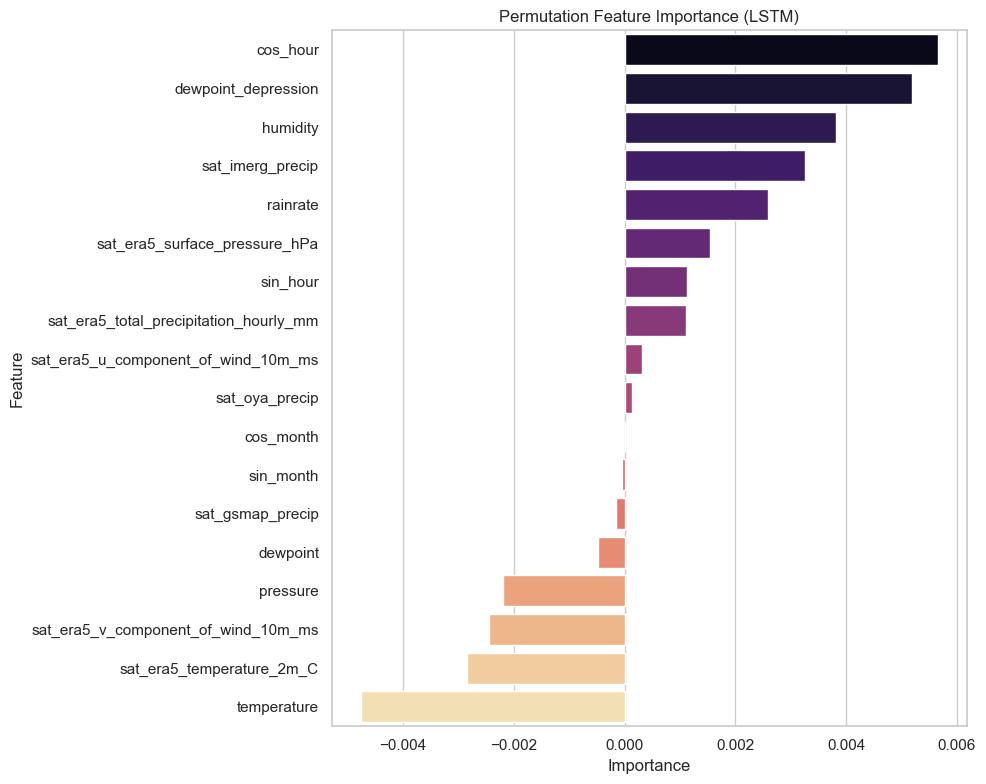

In [7]:
# Sel 6: Eksekusi Utama Prediksi 3-Jam (LSTM)

logger.info(f"\n{'='*50}\nMEMULAI OPTIMASI LSTM 3-JAM\n{'='*50}")
evaluator = ModelEvaluator()

df_features = engineer_features(df_hourly)
df_features['target_amount'] = df_features['rainrate'].shift(-1)
df_features = df_features.dropna()
df_features['target_occurrence'] = (df_features['target_amount'] >= 1.0).astype(int)

if RUN_MODE == "PIPELINE_TEST":
    n = len(df_features)
    train_mask = np.arange(n) < int(n * 0.6)
    val_mask = (np.arange(n) >= int(n * 0.6)) & (np.arange(n) < int(n * 0.8))
    test_mask = np.arange(n) >= int(n * 0.8)
else:
    train_mask = (df_features.index >= '2005-01-01') & (df_features.index <= '2023-12-31')
    val_mask = (df_features.index >= '2024-01-01') & (df_features.index <= '2024-12-31')
    test_mask = (df_features.index >= '2025-01-01') & (df_features.index <= '2025-12-31')

X = df_features.drop(columns=['target_amount', 'target_occurrence'])
y_occ = df_features['target_occurrence']
y_reg = df_features['target_amount']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), index=X.index, columns=X.columns)

def make_3d(X_data, y_occ_data, y_reg_data, lookback):
    Xs, y_o, y_r = [], [], []
    for i in range(len(X_data) - lookback):
        Xs.append(X_data.iloc[i:(i + lookback)].values)
        y_o.append(y_occ_data.iloc[i + lookback])
        y_r.append(y_reg_data.iloc[i + lookback])
    return np.array(Xs), np.array(y_o), np.array(y_r)

# --- STAGE 1: CLASSIFIER OPTIMIZATION ---
def build_lstm_clf(lookback, units, lr, dropout):
    model = Sequential([
        Input(shape=(lookback, X.shape[1])),
        LSTM(units, return_sequences=False),
        Dropout(dropout),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss='binary_crossentropy')
    return model

def objective_occ(trial):
    lookback = trial.suggest_int('lookback', 2, 8)
    units = trial.suggest_int('lstm_units', 16, 64)
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    dropout = trial.suggest_float('dropout_rate', 0.1, 0.5)
    batch_size = trial.suggest_categorical('batch_size', [128, 256, 512])
    
    X_tr_seq, y_tr_o, _ = make_3d(X_scaled[train_mask], y_occ[train_mask], y_reg[train_mask], lookback)
    X_va_seq, y_va_o, _ = make_3d(X_scaled[val_mask], y_occ[val_mask], y_reg[val_mask], lookback)
    
    model = build_lstm_clf(lookback, units, lr, dropout)
    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    model.fit(X_tr_seq, y_tr_o, validation_data=(X_va_seq, y_va_o), epochs=EPOCHS, batch_size=batch_size, callbacks=[es], verbose=0)
    
    val_prob = model.predict(X_va_seq, verbose=0).flatten()
    return brier_score_loss(y_va_o, val_prob)

optuna.logging.set_verbosity(optuna.logging.INFO)
study_occ = optuna.create_study(direction='minimize')
study_occ.optimize(objective_occ, n_trials=OPTUNA_TRIALS)

# Melatih Classifier Terbaik
best_p = study_occ.best_params
best_lookback = best_p['lookback']

X_tr_seq, y_tr_o, y_tr_r = make_3d(X_scaled[train_mask], y_occ[train_mask], y_reg[train_mask], best_lookback)
X_va_seq, y_va_o, y_va_r = make_3d(X_scaled[val_mask], y_occ[val_mask], y_reg[val_mask], best_lookback)
X_te_seq, y_te_o, y_te_r = make_3d(X_scaled[test_mask], y_occ[test_mask], y_reg[test_mask], best_lookback)

clf_best = build_lstm_clf(best_lookback, best_p['lstm_units'], best_p['learning_rate'], best_p['dropout_rate'])
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
csv_logger = CSVLogger(str(evaluator.dirs['plots_train'] / 'training_log.csv'))

history_clf = clf_best.fit(X_tr_seq, y_tr_o, validation_data=(X_va_seq, y_va_o), epochs=EPOCHS, batch_size=best_p['batch_size'], callbacks=[es, reduce_lr, csv_logger], verbose=0)

# Simpan Kurva
plt.figure(figsize=(6,4))
plt.plot(history_clf.history['loss'], label='Train')
plt.title('Training Loss')
plt.legend()
plt.savefig(evaluator.dirs['plots_train'] / 'training_loss.png')
plt.close()

plt.figure(figsize=(6,4))
plt.plot(history_clf.history['val_loss'], label='Validation', color='orange')
plt.title('Validation Loss')
plt.legend()
plt.savefig(evaluator.dirs['plots_train'] / 'validation_loss.png')
plt.close()

plt.figure(figsize=(6,4))
plt.plot(history_clf.history['learning_rate'], label='Learning Rate', color='green')
plt.title('Learning Rate Schedule')
plt.legend()
plt.savefig(evaluator.dirs['plots_train'] / 'learning_rate.png')
plt.close()

try:
    fig = optuna.visualization.plot_optimization_history(study_occ)
    fig.write_image(str(evaluator.dirs['plots_train'] / 'optimization_history.png'))
except: pass

clf_best.save(evaluator.dirs['models_clf'] / 'best_lstm_occ.h5')

# Probability Calibration
iso_reg = IsotonicRegression(out_of_bounds='clip')
val_probs_uncal = clf_best.predict(X_va_seq, verbose=0).flatten()
iso_reg.fit(val_probs_uncal, y_va_o)
joblib.dump(iso_reg, evaluator.dirs['models_cal'] / 'isotonic_calibrator.pkl')

# --- STAGE 2: REGRESSOR OPTIMIZATION ---
rainy_tr = y_tr_o == 1
rainy_va = y_va_o == 1

if np.sum(rainy_tr) > 10:
    X_tr_r, y_tr_r_val = X_tr_seq[rainy_tr], y_tr_r[rainy_tr]
    X_va_r, y_va_r_val = X_va_seq[rainy_va], y_va_r[rainy_va]
    
    def build_lstm_reg(lookback, units, lr, dropout):
        model = Sequential([
            Input(shape=(lookback, X.shape[1])),
            LSTM(units, return_sequences=False),
            Dropout(dropout),
            Dense(1, activation='linear')
        ])
        model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
        return model
        
    def objective_reg(trial):
        units = trial.suggest_int('lstm_units', 16, 64)
        lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
        dropout = trial.suggest_float('dropout_rate', 0.1, 0.5)
        batch_size = trial.suggest_categorical('batch_size', [128, 256, 512])
        
        model = build_lstm_reg(best_lookback, units, lr, dropout)
        es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        model.fit(X_tr_r, y_tr_r_val, validation_data=(X_va_r, y_va_r_val), epochs=EPOCHS, batch_size=batch_size, callbacks=[es], verbose=0)
        preds = model.predict(X_va_r, verbose=0).flatten()
        return mean_squared_error(y_va_r_val, preds)
        
    study_reg = optuna.create_study(direction='minimize')
    study_reg.optimize(objective_reg, n_trials=OPTUNA_TRIALS)
    
    best_p_reg = study_reg.best_params
    reg_best = build_lstm_reg(best_lookback, best_p_reg['lstm_units'], best_p_reg['learning_rate'], best_p_reg['dropout_rate'])
    reg_best.fit(X_tr_r, y_tr_r_val, validation_data=(X_va_r, y_va_r_val), epochs=EPOCHS, batch_size=best_p_reg['batch_size'], callbacks=[EarlyStopping(patience=5, restore_best_weights=True)], verbose=0)
    reg_best.save(evaluator.dirs['models_reg'] / 'best_lstm_reg.h5')
else:
    reg_best = None

# --- EVALUATION ---
test_probs_uncal = clf_best.predict(X_te_seq, verbose=0).flatten()
test_probs_cal = iso_reg.predict(test_probs_uncal)
test_preds_occ = (test_probs_cal >= 0.5).astype(int)

clf_metrics, meteo_metrics = evaluator.evaluate_classification(y_te_o, test_probs_uncal, test_probs_cal, test_preds_occ)

evaluator.plot_reliability_diagram(y_te_o, test_probs_uncal, test_probs_cal)
evaluator.plot_probability_distribution(test_probs_cal)
evaluator.plot_calibration_curve(y_te_o, test_probs_uncal)

evaluator.plot_confusion_matrix(y_te_o, test_preds_occ)
evaluator.plot_roc_curve(y_te_o, test_probs_cal)
evaluator.plot_precision_recall_curve(y_te_o, test_probs_cal)
evaluator.plot_threshold_analysis(y_te_o, test_probs_cal)

final_preds = np.zeros_like(test_preds_occ, dtype=float)
if reg_best is not None:
    rainy_pred_mask = test_preds_occ == 1
    if np.any(rainy_pred_mask):
        final_preds[rainy_pred_mask] = reg_best.predict(X_te_seq[rainy_pred_mask], verbose=0).flatten()
        
actual_rainy = y_te_o == 1
reg_metrics = {}
if np.any(actual_rainy):
    reg_metrics = evaluator.evaluate_regression(y_te_r[actual_rainy], final_preds[actual_rainy])
    evaluator.plot_prediction_vs_observation(y_te_r[actual_rainy], final_preds[actual_rainy])
    evaluator.plot_residual_distribution(final_preds[actual_rainy] - y_te_r[actual_rainy])
    evaluator.plot_qq_plot(final_preds[actual_rainy] - y_te_r[actual_rainy])
    evaluator.plot_error_distribution(y_te_r[actual_rainy], final_preds[actual_rainy])

evaluator.plot_timeseries_prediction_vs_observation(y_te_r, final_preds, X_scaled[test_mask].index[best_lookback:])
evaluator.plot_rainfall_event_comparison(y_te_r, final_preds)
evaluator.plot_cumulative_rainfall(y_te_r, final_preds, X_scaled[test_mask].index[best_lookback:])

evaluator.generate_report(len(X_tr_seq), len(X_va_seq), len(X_te_seq), X.columns.tolist(), clf_metrics, meteo_metrics, reg_metrics, "Keras LSTM")

# --- PERMUTATION IMPORTANCE ---
logger.info("Menghasilkan Permutation Importance Plot untuk LSTM...")
class KerasClassifierWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model): self.model = model
    def fit(self, X, y): return self
    def predict(self, X): return (self.model.predict(X, verbose=0) >= 0.5).astype(int)
    def predict_proba(self, X): return self.model.predict(X, verbose=0)

keras_wrapper = KerasClassifierWrapper(clf_best)
X_pi = X_va_seq[:500]
y_pi = y_va_o[:500]

def score_func(estimator, X, y):
    return roc_auc_score(y, estimator.predict_proba(X))

try:
    # Memerlukan custom loop karena sklearn PI expect 2D
    baseline_score = score_func(keras_wrapper, X_pi, y_pi)
    importances = []
    
    for i in range(X_pi.shape[2]): # Loop over features
        X_perm = X_pi.copy()
        # Mengacak fitur i pada semua timestep
        for j in range(X_perm.shape[0]):
            np.random.shuffle(X_perm[j, :, i])
        perm_score = score_func(keras_wrapper, X_perm, y_pi)
        importances.append(baseline_score - perm_score)
        
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
    feat_imp = feat_imp.sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(data=feat_imp.head(20), x='Importance', y='Feature', palette='magma')
    plt.title("Permutation Feature Importance (LSTM)")
    plt.tight_layout()
    plt.savefig(evaluator.dirs['plots_feat'] / 'permutation_importance.png')
    
    feat_imp.to_csv(evaluator.dirs['plots_feat'] / 'feature_ranking.csv', index=False)
    
except Exception as e:
    logger.warning(f"Gagal melakukan Permutation analisis: {e}")

logger.info("Proses Eksekusi LSTM Selesai!")

